# Colorization as a Pretext Task for Self-Supervised Learning

The main goal of this project is to investigate if image colorization is a good pretext task for self-supervised learning.

Some code is already provided. You can modify most of the code unless specifically stated that some section should not be changed.

## Image Colorization

Image colorization is the process of adding colours to a black and white or grayscale images, like in the example seen below.
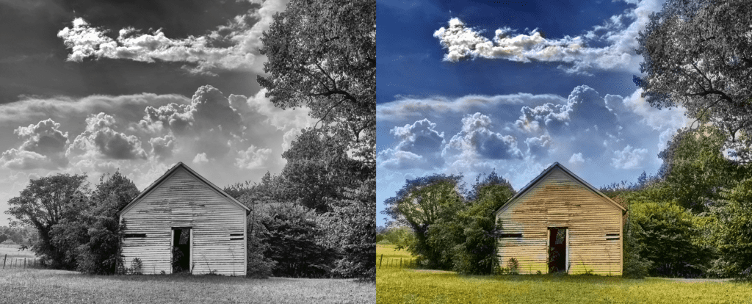



## Self-supervised Learning

According to [Wikipedia](https://en.wikipedia.org/wiki/Self-supervised_learning#:~:text=Self%2Dsupervised%20learning%20(SSL),help%20with%20downstream%20learning%20tasks): "Self-supervised learning (SSL) refers to a machine learning paradigm, and corresponding methods, for processing unlabeled data to obtain useful representations that can help with downstream learning tasks."

For a brief introduction on SSL see: https://youtu.be/bfCs3wqRSQY

The usual pipeline of an SSL application is:

1.   pre train a neural network on a pretext task (e.g. rotation, colorization, inpainting, etc)
2.   transfer the weights of the pre trained network to the final downstream task (e.g. classification)



## Image Colorization as the SSL Pretext/Proxy Task

The goal of this project is to use image colorization as the pretext task for a classification downstream task.

For an example of such a pipeline see: https://openaccess.thecvf.com/content_cvpr_2017/papers/Larsson_Colorization_as_a_CVPR_2017_paper.pdf

Therefore, this project entails:

1. Baseline - training a ResNet18 model (**from scratch**, i.e. without ImageNet pretraining) on the CIFAR10 dataset
2. Colorization - training an image colorization model
3. Using (part of) the model learned in 2. to initialize the weights of another ResNet18 model and finetuning it on the CIFAR10 dataset
4. Compare the **test set** accuracy of both models (1. and 3.)



In [1]:
from matplotlib import pyplot as plt
import numpy as np
import math
import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, models, transforms
import cv2
import shutil
from tqdm import tqdm
import random
random.seed(42) # DO NOT CHANGE THIS
torch.manual_seed(42) # DO NOT CHANGE THIS
import time
import torchmetrics

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Exercise 1

Train a ResNet18 model (**from scratch, i.e. without ImageNet pretraining!!**) on the CIFAR10 dataset.

Evaluate the obtained model on the **test set** in terms of accuracy.

In [6]:
# Some hyperparameters have already been defined. Feel free to experiment and change them as you see fit.
batch_size = 32
num_workers = 2
epochs = 5
learning_rate = 1e-3

#define the device to use
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [7]:
# DO NOT CHANGE THIS CELL (particularly the shuffling)
train_dataset = datasets.CIFAR10(root='dataset', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.CIFAR10(root='dataset', train=False, transform=transforms.ToTensor())
train_dataset, val_dataset = random_split(train_dataset, [0.9, 0.1])
len(train_dataset), len(val_dataset), len(test_dataset)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

Files already downloaded and verified


### Building model

In [10]:
class Block(nn.Module):
    
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(Block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.identity_downsample = identity_downsample
        
    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x
    
    
class ResNet_18(nn.Module):
    
    def __init__(self, image_channels, num_classes):
        
        super(ResNet_18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        #resnet layers
        self.layer1 = self.__make_layer(64, 64, stride=1)
        self.layer2 = self.__make_layer(64, 128, stride=2)
        self.layer3 = self.__make_layer(128, 256, stride=2)
        self.layer4 = self.__make_layer(256, 512, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        
    def __make_layer(self, in_channels, out_channels, stride):
        
        identity_downsample = None
        if stride != 1:
            identity_downsample = self.identity_downsample(in_channels, out_channels)
            
        return nn.Sequential(
            Block(in_channels, out_channels, identity_downsample=identity_downsample, stride=stride), 
            Block(out_channels, out_channels)
        )
        
    def forward(self, x):
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = x.view(x.shape[0], -1)
        x = self.fc(x)
        return x 
    
    def identity_downsample(self, in_channels, out_channels):
        
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(out_channels)
        )

In [5]:
model = ResNet_18(3, 10)
model.to(device)

ResNet_18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Block(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): Block(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=

### Training

In [6]:
# define loss
criterion = nn.CrossEntropyLoss()

# define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay=1e-4)

# calculate steps per epoch for training and test set
train_steps = len(train_dataloader)
test_steps = len(val_dataloader)


In [ ]:
startTime = time.time()

for epoch in tqdm(range(epochs)):
    
    # Setup train loss and train accuracy values
    train_loss = 0.0
    test_loss = 0.0
    train_acc = 0
    test_acc = 0
    
    # switch on autograd
    with torch.enable_grad():
        
        # set the model in training mode
        model.train()
        
        for X, y in train_dataloader:
            
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # make the predictions
            y_pred = model(X)
            
            # calculate the loss
            loss = criterion(y_pred, y)
            train_loss += loss.item()

            # calculate the accuracy
            _, pred = torch.max(y_pred, 1)
            acc = torch.sum(pred == y.data) / batch_size
            train_acc += acc

            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Loss backward and optimizer step
            loss.backward()
            optimizer.step()
            

    # switch off autograd
    with torch.no_grad():

        # set the model in evaluation mode
        model.eval()

        for X,y in val_dataloader:
            
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # make the predictions
            y_pred = model(X)

            # calculate the loss
            loss = criterion(y_pred, y)
            test_loss += loss.item()

            # calculate the accuracy
            _, pred = torch.max(y_pred, 1)
            acc = torch.sum(pred == y.data) / batch_size
            test_acc += acc
   
    # Adjust metrics to get average loss per batch 
    train_loss = train_loss / train_steps
    test_loss = test_loss / test_steps
    train_acc = train_acc / train_steps
    test_acc = test_acc / test_steps
    
    # print the model training and validation information
    print("[INFO] EPOCH: {}/{}".format(epoch + 1, epochs))
    print("Train loss: {:.6f}, Train acc: {:.6f}, Val loss: {:.4f}, Val acc: {:.6f}"\
        .format(train_loss, train_acc, test_loss, test_acc))

# display the total time needed to perform the training
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

In [8]:
torch.save(model.state_dict(), './resnet18_state_dict.pt')

## Testing

In [9]:
test_acc = 0.0

for X,y in test_dataloader:
    
    with torch.no_grad():
            
        model.eval()
        
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # make the predictions
        y_pred = model(X)
        _, pred = torch.max(y_pred, 1)

        acc = torch.sum(pred == y.data) / batch_size
        test_acc += acc.item()
    
print("Accuracy in test set: {:.6f}".format(test_acc / len(test_dataloader)))

Accuracy in test set: 0.698582


## Exercise 2

Train an image colorization network on the CIFAR10 dataset.

We will be using the network proposed in https://lukemelas.github.io/image-colorization.html and depicted below.

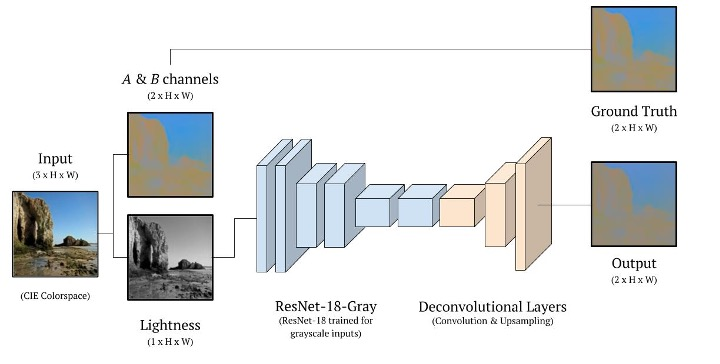

The network takes as input the grayscale version of an image and predicts its A and B channels (of the LAB color space).

The encoder part of the network is made of some layers of the ResNet18 architecture, but adapted to take grayscale inputs. See the implementation below for more details.

In [4]:
class ColorizationDataset(Dataset):
    
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # get the RGB image from torchvision's CIFAR10 dataset, convert it back from tensor to a numpy array
        input_tensor = self.base_dataset[idx][0]
        img_rgb = input_tensor.permute((1, 2, 0))
        img_rgb = np.asarray(img_rgb)
        
        # converting to Lab colour-space
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2Lab)
        
        # input image gray scale
        input_image = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        input_image = torch.tensor(input_image).unsqueeze(0)
        
        # ground-truth ( & b)
        gt = (img_lab[...,1:] + 128) / 255
        gt = torch.tensor(gt).permute((2, 0, 1))
        
        return img_rgb, input_image, gt

In [8]:
# DO NOT CHANGE THIS CELL (particularly the shuffling)
train_dataset_colour = ColorizationDataset(train_dataset)
val_dataset_colour = ColorizationDataset(val_dataset)
test_dataset_colour = ColorizationDataset(test_dataset)

train_dataloader_colour = DataLoader(train_dataset_colour, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader_colour = DataLoader(val_dataset_colour, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_dataloader_colour = DataLoader(test_dataset_colour, batch_size=batch_size, shuffle=False, num_workers=num_workers)

### Building model

The torchvision CIFAR10 dataset also needs to be adapted to the colorization problem. Below you can find part of the code to do this. It builds upon the torchvision dataset. Introduce the necessary adaptations for the colorization problem.

In [31]:
class ColorizationNet(nn.Module):
    def __init__(self, input_size=32):
        super(ColorizationNet, self).__init__()
        MIDLEVEL_FEATURE_SIZE = 128

        ## First half: ResNet
        resnet = models.resnet18(weights=None)
        # Change first conv layer to accept single-channel (grayscale) input
        resnet.conv1.weight = nn.Parameter(resnet.conv1.weight.sum(dim=1).unsqueeze(1)) 
        # Extract midlevel features from ResNet-gray
        self.midlevel_resnet = nn.Sequential(*list(resnet.children())[0:6])

        ## Second half: Upsampling
        self.upsample = nn.Sequential(     
          nn.Conv2d(MIDLEVEL_FEATURE_SIZE, 128, kernel_size=3, stride=1, padding=1),
          nn.BatchNorm2d(128),
          nn.ReLU(),
          nn.Upsample(scale_factor=2),
          nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn.Upsample(scale_factor=2),
          nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
          nn.BatchNorm2d(32),
          nn.ReLU(),
          nn.Conv2d(32, 2, kernel_size=3, stride=1, padding=1),
          nn.Upsample(scale_factor=2)
        )

    def forward(self, input):

        # Pass input through ResNet-gray to extract features
        midlevel_features = self.midlevel_resnet(input)

        # Upsample to get colors
        output = self.upsample(midlevel_features)
        return output

In [11]:
# Loading
model = ResNet_18(3, 10)
model.load_state_dict(torch.load('/kaggle/input/colorization-dataset1/resnet18_state_dict.pt', map_location=torch.device('cpu')))

<All keys matched successfully>

In [35]:
colornet = ColorizationNet(model)
colornet.to(device)

ColorizationNet(
  (midlevel_resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

### Training model

In [34]:
# hyperparameters 

epochs = 10
learning_rate = 1e-2


In [36]:
# define loss
criterion = nn.MSELoss()

# define optimizer
optimizer = torch.optim.Adam(colornet.parameters(), lr = learning_rate, weight_decay=0.0)

# define mse metric
mean_squared_error = torchmetrics.MeanSquaredError().to(device)

#lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, verbose=True)

# calculate steps per epoch for training and test set
train_steps = len(train_dataloader_colour)
test_steps = len(val_dataloader_colour)

In [37]:
startTime = time.time()

for epoch in tqdm(range(epochs)):
    
    # Setup train loss and train accuracy values
    train_loss = 0.0
    test_loss = 0.0
    train_mse = 0.0
    test_mse = 0.0
    
    # switch on autograd
    with torch.enable_grad():
        
        # set the model in training mode
        colornet.train()
        
        for _, X, y in train_dataloader_colour:
            
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # make the predictions
            y_pred = colornet(X)
            
            # calculate the loss
            loss = criterion(y_pred, y)
            train_loss += loss.item()

            # calculate the mse
            mse = mean_squared_error(y_pred, y)
            train_mse += mse.item()

            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Loss backward and optimizer step
            loss.backward()
            optimizer.step()
            

    # switch off autograd
    with torch.no_grad():

        # set the model in evaluation mode
        colornet.eval()

        for _, X, y in val_dataloader_colour:
            
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # make the predictions
            y_pred = colornet(X)
            
            # calculate the loss
            loss = criterion(y_pred, y)
            test_loss += loss.item()

            # calculate the mse
            mse = mean_squared_error(y_pred, y)
            test_mse += mse.item()
   
    # Adjust metrics to get average loss per batch 
    train_loss = train_loss / train_steps
    test_loss = test_loss / test_steps
    train_mse = train_mse / train_steps
    test_mse = test_mse / test_steps

    # print the model training and validation information
    print("[INFO] EPOCH: {}/{}".format(epoch + 1, epochs))
    print("Train loss: {:.6f}, Train mse: {:.6f}, Val loss: {:.4f}, Val mse: {:.6f}"\
        .format(train_loss, train_mse, test_loss, test_mse))

# display the total time needed to perform the training
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

 10%|█         | 1/10 [00:29<04:24, 29.39s/it]

[INFO] EPOCH: 1/10
Train loss: 0.005184, Train mse: 0.005184, Val loss: 0.0030, Val mse: 0.002956


 20%|██        | 2/10 [00:58<03:52, 29.04s/it]

[INFO] EPOCH: 2/10
Train loss: 0.002650, Train mse: 0.002650, Val loss: 0.0026, Val mse: 0.002624


 30%|███       | 3/10 [01:26<03:21, 28.86s/it]

...

[INFO] EPOCH: 8/10
Train loss: 0.002411, Train mse: 0.002411, Val loss: 0.0024, Val mse: 0.002395


 90%|█████████ | 9/10 [04:19<00:28, 28.73s/it]

[INFO] EPOCH: 9/10
Train loss: 0.002394, Train mse: 0.002394, Val loss: 0.0024, Val mse: 0.002397


100%|██████████| 10/10 [04:47<00:00, 28.80s/it]

[INFO] EPOCH: 10/10
Train loss: 0.002381, Train mse: 0.002381, Val loss: 0.0024, Val mse: 0.002391
[INFO] total time taken to train the model: 287.97s


In [38]:
torch.save(colornet.state_dict(), './colornet_state_dict.pt')

### Testing model

In [25]:
test_mse = 0.0
pred_ab = []

for img_rgb, X, y in test_dataloader_colour:
    
    # switch off autograd
    with torch.no_grad():

        colornet.eval()
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # make the predictions
        y_pred = colornet(X)

        # calculate the mse
        mse = mean_squared_error(y_pred, y)
        test_mse += mse.item()

        [pred_ab.append(i) for i in y_pred.to(device)]

print("MSE in test set: {:.6f}".format(test_mse / len(test_dataloader_colour)))

MSE in test set: 0.002370


### Displaying results

In [26]:
# note that you can use this function to visualize your model's predictions
def display_image_grid(dataset, pred_images, num_images = 10):
    figure, ax = plt.subplots(nrows=num_images, ncols=3, figsize=(10,24))
    
    for i in range(num_images):
        rgb_img = dataset.__getitem__(i)[0]
        input_img = dataset.__getitem__(i)[1].permute(1,2,0).cpu().detach().numpy() * 100
        output_img = pred_ab[i].permute(1,2,0).cpu().detach().numpy() * 255 - 128 
        lab_img_pred = np.concatenate([input_img, output_img], axis=2)
        rgb_img_pred = cv2.cvtColor(np.asarray(lab_img_pred), cv2.COLOR_Lab2RGB)

        # plot
        ax[i, 0].imshow(rgb_img)
        ax[i, 1].imshow(input_img, cmap='gray')
        ax[i, 2].imshow(rgb_img_pred)

        ax[i, 0].set_title("Ground-truth")
        ax[i, 1].set_title("Input")
        ax[i, 2].set_title("Predicted")

        ax[i, 0].set_axis_off()
        ax[i, 1].set_axis_off()
        ax[i, 2].set_axis_off()
        
    plt.tight_layout()
    plt.show()

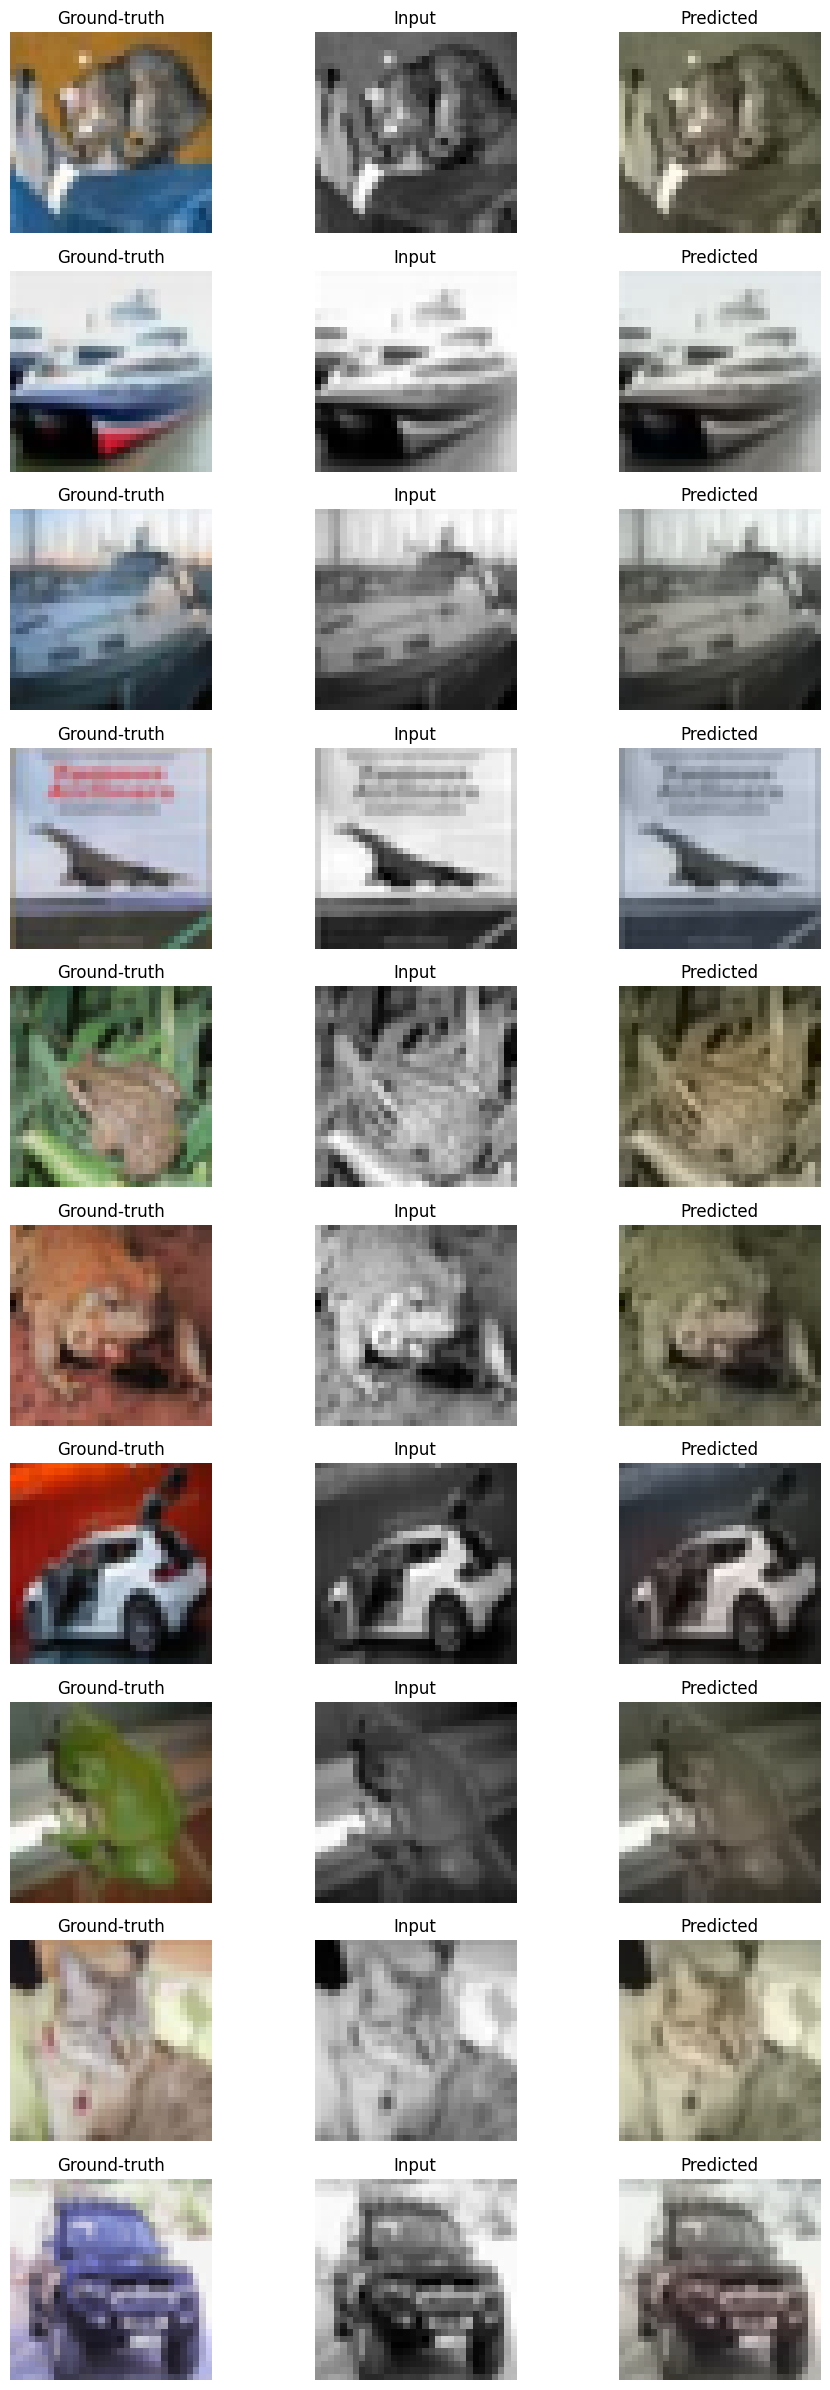

In [27]:
display_image_grid(test_dataset_colour, pred_ab)

## Exercise 3

Retrain a new ResNet18, but now transfer the weights learned from the ColorizationNet.

You need to take into account some aspects:
*   The input of the ColorizationNet only accepts 1 channel (grayscale image), so it needs to be reconverted into a 3 channel image. As the authors of the "Colorization as a Proxy Task for Visual Understanding" paper state: "When colorization is re-introduced, we convert the grayscale filters in conv1_1 to RGB (replicate to all three channels, divide by three) and let them fine-tune on the downstream task.".
*   The ColorizationNet does not use all layers of the ResNet18 architecture, so you can only transfer the weights of the layers that both have in common.
*  Don't forget that only certain layers have learnable weights (e.g. pooling/ReLU layers are not learned), so, naturally, only those can be transfered.



### Building model

In [39]:
# Loading
model = ResNet_18(3, 10)
colornet = ColorizationNet(model)
colornet.load_state_dict(torch.load('./colornet_state_dict.pt'))


<All keys matched successfully>

In [40]:
# Changing input from 1 to 3
colornet.midlevel_resnet[0] = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False) # Replace this with your custom layer
colornet_weights = colornet.midlevel_resnet

# Transfering colornet weights to resnet18
resnet_colorweights = models.resnet18(weights = colornet_weights)
resnet_colorweights.to(device)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Training

In [42]:
epochs = 8
learning_rate = 1e-4

# define loss
criterion = nn.CrossEntropyLoss()
# define optimizer
optimizer = torch.optim.Adam(resnet_colorweights.parameters(), lr = learning_rate, weight_decay=1e-4)

# calculate steps per epoch for training and test set
train_steps = len(train_dataloader)
test_steps = len(val_dataloader)

In [43]:
startTime = time.time()
val_acc_history = []

for epoch in tqdm(range(epochs)):
    
    # Setup train loss and train accuracy values
    train_loss = 0.0
    test_loss = 0.0
    train_acc = 0
    test_acc = 0
    
    # switch on autograd
    with torch.enable_grad():
        
        # set the model in training mode
        resnet_colorweights.train()
        
        for X, y in train_dataloader:
            
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # make the predictions
            y_pred = resnet_colorweights(X)
            
            # calculate the loss
            loss = criterion(y_pred, y)
            train_loss += loss.item()

            # calculate the accuracy
            _, pred = torch.max(y_pred, 1)
            acc = torch.sum(pred == y.data) / batch_size
            train_acc += acc

            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Loss backward and optimizer step
            loss.backward()
            optimizer.step()
            

    # switch off autograd
    with torch.no_grad():

        # set the model in evaluation mode
        resnet_colorweights.eval()

        for X,y in val_dataloader:
            
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # make the predictions
            y_pred = resnet_colorweights(X)

            # calculate the loss
            loss = criterion(y_pred, y)
            test_loss += loss.item()

            # calculate the accuracy
            _, pred = torch.max(y_pred, 1)
            acc = torch.sum(pred == y.data) / batch_size
            test_acc += acc
   
    # Adjust metrics to get average loss per batch 
    train_loss = train_loss / train_steps
    test_loss = test_loss / test_steps
    train_acc = train_acc / train_steps
    test_acc = test_acc / test_steps
    
    # print the model training and validation information
    print("[INFO] EPOCH: {}/{}".format(epoch + 1, epochs))
    print("Train loss: {:.6f}, Train acc: {:.6f}, Val loss: {:.4f}, Val acc: {:.6f}"\
        .format(train_loss, train_acc, test_loss, test_acc))

# display the total time needed to perform the training
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

 12%|█▎        | 1/8 [00:26<03:02, 26.07s/it]

[INFO] EPOCH: 1/8
Train loss: 1.523513, Train acc: 0.573561, Val loss: 0.8037, Val acc: 0.722333


 25%|██▌       | 2/8 [00:50<02:28, 24.82s/it]

[INFO] EPOCH: 2/8
Train loss: 0.739780, Train acc: 0.746424, Val loss: 0.6461, Val acc: 0.774283


 38%|███▊      | 3/8 [01:13<02:01, 24.39s/it]

...

[INFO] EPOCH: 6/8
Train loss: 0.277975, Train acc: 0.904873, Val loss: 0.6140, Val acc: 0.807126


 88%|████████▊ | 7/8 [02:50<00:24, 24.12s/it]

[INFO] EPOCH: 7/8
Train loss: 0.218170, Train acc: 0.924174, Val loss: 0.6401, Val acc: 0.801553


100%|██████████| 8/8 [03:14<00:00, 24.32s/it]

[INFO] EPOCH: 8/8
Train loss: 0.179414, Train acc: 0.937278, Val loss: 0.6645, Val acc: 0.800557
[INFO] total time taken to train the model: 194.55s


In [44]:
torch.save(resnet_colorweights.state_dict(), './resnet_colorweights_state_dict.pt')

### Testing

In [45]:
## Evaluating the model

test_acc = 0.0

for X,y in test_dataloader:
    
    # switch off autograd
    with torch.no_grad():
        resnet_colorweights.eval()

        # Send data to target device
        X, y = X.to(device), y.to(device)

        # make the predictions
        y_pred = resnet_colorweights(X)
        _, pred = torch.max(y_pred, 1)

        acc = torch.sum(pred == y.data) / batch_size
        test_acc += acc.cpu().numpy()
    
print("Accuracy in test set: {:.6f}".format(test_acc / len(test_dataloader)))

Accuracy in test set: 0.803115


## Comparing performance 

Accuracy ResNet18 from scratch: **0.698582**

Accuracy ResNet18 finetuned after colorization: **0.803115**